# Clustering II (Linkage / Hierarchical)

Hierarchical Clustering adalah metode *unsupervised learning* yang membangun sebuah hierarki atau struktur pohon dari cluster, berbeda dengan K-Means yang membutuhkan jumlah cluster (K) ditentukan di awal.

Ada dua pendekatan utama:
- **Agglomerative** (bottom-up): setiap titik data dimulai sebagai cluster individual, lalu pasangan cluster terdekat digabungkan secara beruntun.
- **Divisive** (top-down): dimulai dari satu cluster besar, lalu dipecah rekursif jadi cluster lebih kecil.

Kunci dari Agglomerative Clustering adalah **linkage criteria** — cara mengukur jarak antar cluster (bukan antar titik): *Single*, *Complete*, *Average*, dan *Ward* (default di sklearn).

**Dendrogram** adalah diagram pohon yang merekam urutan penggabungan cluster; dengan "memotong" dendrogram di ketinggian tertentu, kita bisa menentukan jumlah cluster.

**Cophenetic Correlation Coefficient** adalah metrik yang mengukur seberapa setia dendrogram merepresentasikan jarak asli antar sampel — pelengkap Silhouette Score untuk mengevaluasi kualitas struktur pohonnya, bukan hanya hasil potongannya.

### 1.1 Install Library

In [ ]:
#pip install numpy pandas scikit-learn scipy matplotlib seaborn

### 1.2 Import Library yang Dibutuhkan

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

### 1.3 Mempersiapkan Dataset
Pertemuan ini menggunakan dataset dari scikit-learn, yaitu dataset **Iris** (150 sampel, 4 fitur) — sama seperti Modul 4.
- #### 1.3.1 Import Dataset

In [5]:
iris = load_iris(as_frame=True)
X = iris.data
y_true = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


- #### 1.3.2 Standardisasi Data
Sama seperti K-Means, Hierarchical Clustering menghitung jarak, sehingga semua fitur perlu berada pada skala yang sama.

---
## 2. Agglomerative Clustering

Coba 3 kriteria linkage sekaligus: `ward`, `average`, `complete`. Untuk `linkage="ward"`, `metric` WAJIB `"euclidean"`.

In [6]:
agg_ward = AgglomerativeClustering(n_clusters=3, linkage='ward', metric='euclidean')
labels_ward = agg_ward.fit_predict(X_scaled)

agg_avg = AgglomerativeClustering(n_clusters=3, linkage='average', metric='euclidean')
labels_avg = agg_avg.fit_predict(X_scaled)

agg_comp = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels_comp = agg_comp.fit_predict(X_scaled)

print("Label Sampel Ward:", labels_ward[:10])
print("Label Sampel Average:", labels_avg)
print("Label Sampel Complete:", labels_comp)


Label Sampel Ward: [1 1 1 1 1 1 1 1 1 1]
Label Sampel Average: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1
 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
Label Sampel Complete: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 0 0 0 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 0 0 0 2 0 2 2 0 2 2 2 0 0 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


---
## 3. Evaluasi Singkat (Silhouette Score)

Hitung Silhouette Score untuk ketiga hasil linkage di atas.

In [7]:
for name, labels in {"ward" : labels_ward, "average": labels_avg, 
"complete": labels_comp}.items():
  score = silhouette_score(X_scaled, labels)
  print(f"Silhouette Score {name}: {score:.3f}")

Silhouette Score ward: 0.447
Silhouette Score average: 0.480
Silhouette Score complete: 0.450


---
## 4. Dendrogram (SciPy)

Bangun dendrogram dari linkage `ward` untuk melihat keseluruhan proses penggabungan secara visual. Gunakan `truncate_mode='lastp', p=15` supaya dendrogram tetap terbaca (150 sampel Iris terlalu padat kalau ditampilkan penuh).

### 4.1 Dendrogram Utama (Linkage Ward)

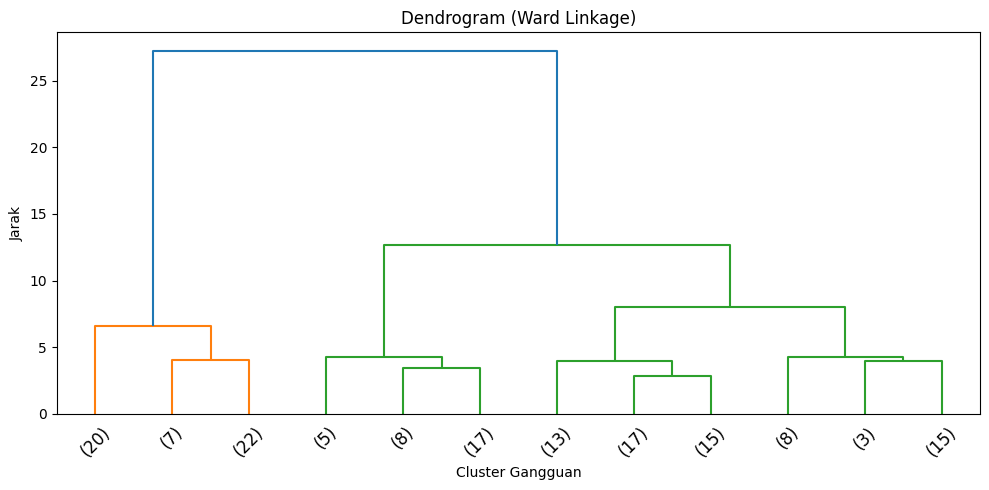

In [ ]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(
    Z, 
    truncate_mode='lastp',
    p=12,
    leaf_rotation=45.,
    leaf_font_size=12.
)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Cluster Gangguan")
plt.ylabel("Jarak")
plt.tight_layout()
plt.show()

### 4.2 Menentukan Titik Potong (max_d)

Opsional: menyorot garis potong pada ketinggian tertentu (`max_d`) untuk menunjukkan bagaimana K ditentukan dari dendrogram secara visual.

Ketinggian Merge yang Membentuk 5 cluster : 4.243
Ketinggian Merge berikutnya turun ke 5 cluster : 8.005
max_d dipakai (titik tengah) : 6.124


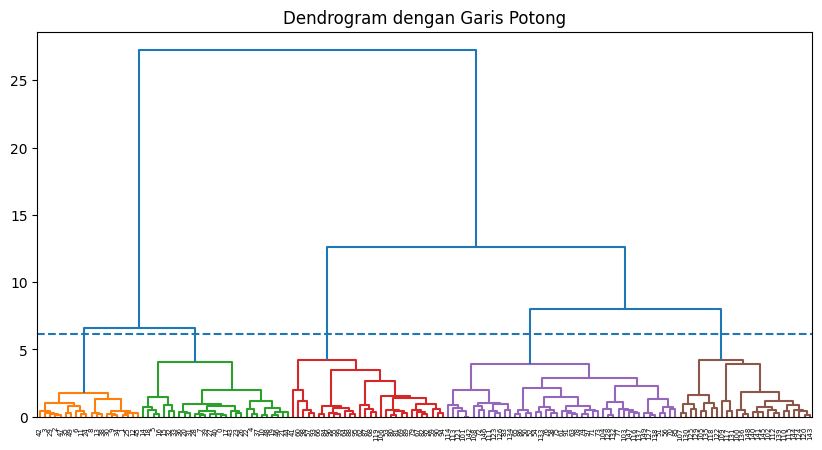

In [19]:
k_target = 5
n = X_scaled.shape[0]

idx_masuk_k = n- k_target -1
idx_keluar_k = n- k_target +1
max_d = (Z[idx_masuk_k, 2] + Z[idx_keluar_k, 2]) / 2

print(f"Ketinggian Merge yang Membentuk {k_target} cluster : {Z [idx_masuk_k,2]:.3f}")
print(f"Ketinggian Merge berikutnya turun ke {k_target} cluster : {Z [idx_keluar_k,2]:.3f}")
print(f"max_d dipakai (titik tengah) : {max_d:.3f}")

plt.figure(figsize=(10, 5))
dendrogram(Z, color_threshold=max_d)
plt.axhline(y=max_d, linestyle="--")
plt.title("Dendrogram dengan Garis Potong")
plt.show()

### 4.3 Bandingkan Dendrogram Keempat Linkage (Ward vs Single vs Complete vs Average)

Bangun dendrogram untuk `ward`, `single`, `complete`, dan `average` sekaligus dalam 1 grid 2x2 (`plt.subplots(2, 2)`), lalu bandingkan bentuk percabangannya secara visual.

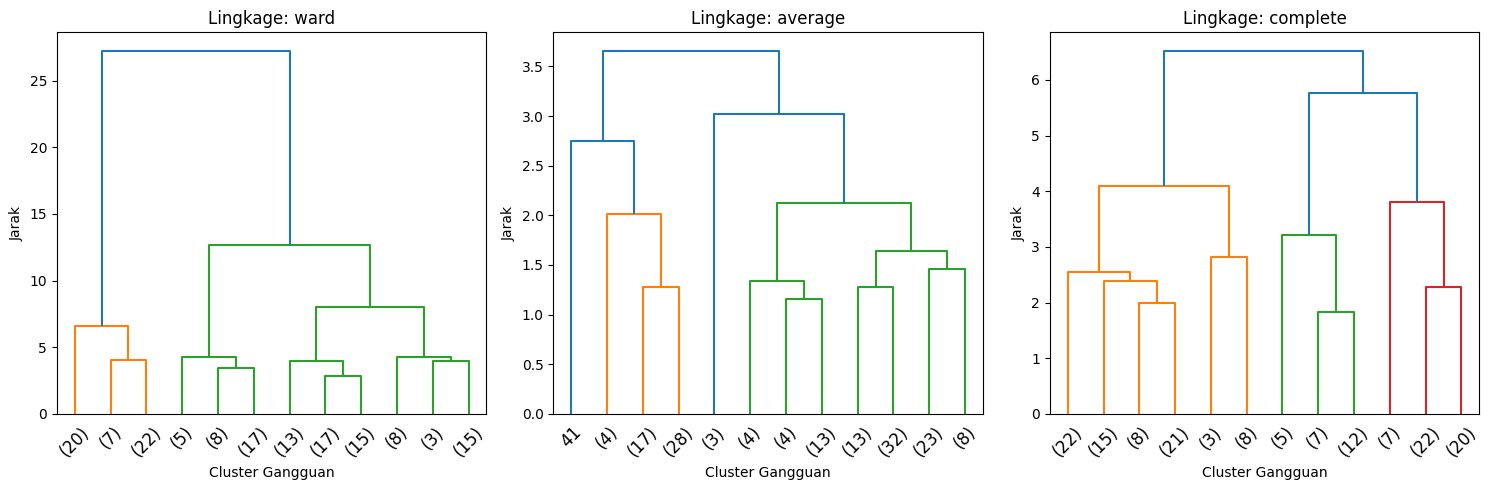

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.ravel()

for ax, method in zip(axes, ['ward', 'average', 'complete', 'average']):
   Z_m = linkage(X_scaled, method=method)
   dendrogram(Z_m, truncate_mode='lastp', p=12, leaf_rotation=45., leaf_font_size=12., ax=ax)
   ax.set_title(f"Lingkage: {method}")
   ax.set_xlabel("Cluster Gangguan")
   ax.set_ylabel("Jarak")

   plt.tight_layout()

Hitung ukuran (jumlah anggota) tiap cluster untuk `n_clusters=3` pada keempat linkage tersebut (gunakan `metric="euclidean"` untuk semuanya supaya adil dibandingkan). Identifikasi linkage mana yang menghasilkan cluster paling timpang (indikasi *chaining*).

In [25]:
print("Ukuran Cluster (n_clusters=3) per linkage -- makin timpang, makin kuat indikasi chaining")

for method in ["ward", "single", "complete", "average"]:
    agg = AgglomerativeClustering(
        n_clusters=3,
        linkage=method,
        metric='euclidean'
    )
    
    labels = agg.fit_predict(X_scaled)
    sizes = sorted(
        [int(s) for s in np.bincount(labels)],
        reverse=True
    )
    
    print(f"{method}: {sizes}")

Ukuran Cluster (n_clusters=3) per linkage -- makin timpang, makin kuat indikasi chaining
ward: [71, 49, 30]
single: [100, 49, 1]
complete: [77, 49, 24]
average: [97, 50, 3]


---
## 5. Evaluasi Dendrogram Menggunakan Cophenetic Correlation Coefficient

Hitung Cophenetic Correlation Coefficient untuk linkage `ward`, lalu bandingkan dengan `average`, `complete`, dan `single`.

---
## 6. Heatmap

Visualisasikan seluruh fitur (dalam skala z-score) untuk semua sampel, diurutkan berdasarkan cluster hasil linkage `ward`.

---
## 7. Catatan Penting Praktikum

- Standardisasi WAJIB sebelum Agglomerative Clustering.
- `linkage="ward"` HARUS dipasangkan dengan `metric="euclidean"`.
- Beda linkage bisa menghasilkan cluster yang berbeda pada K yang sama — bandingkan minimal 2 metrik evaluasi (Silhouette Score DAN Cophenetic Correlation Coefficient) sebelum memilih linkage terbaik.
- Cophenetic Correlation Coefficient dan Silhouette Score mengukur hal berbeda (struktur pohon vs kualitas potongan) — sepakat di satu dataset bukan jaminan akan selalu sepakat di dataset lain.

---
## 8. Latihan

Ganti dataset ke Wine (`sklearn.datasets.load_wine`).

1. Jalankan `AgglomerativeClustering` untuk `n_clusters = 3` dengan `linkage = ["ward", "average", "complete", "single"]`. Catat Silhouette Score tiap kombinasi.
2. Bangun dendrogram untuk `method="ward"` dan tentukan jumlah cluster yang wajar dari ketinggian merge yang besar.
3. Buat heatmap z-score fitur yang diurutkan menurut label cluster terbaik.
4. Bandingkan hasil Ward vs Average: mana yang menghasilkan cluster lebih seimbang? Dukung dengan Silhouette Score dan visualisasi.
5. (Opsional) Coba `metric` lain (mis. `cosine`) untuk linkage non-Ward dan diskusikan dampaknya pada bentuk cluster/score.
6. Hitung Cophenetic Correlation Coefficient untuk tiap metode linkage yang dicoba di poin 1. Apakah metode dengan Silhouette Score tertinggi juga memiliki koefisien kophenetik tertinggi? Jelaskan kemungkinan penyebabnya jika jawabannya tidak.